Root Gini: 0.5
Root Entropy: 1.0
Weighted Gini after split: 0.0
Information Gain: 1.0
Gini Accuracy: 1.0
Entropy Accuracy: 0.9777777777777777
Feature Importance (Gini): [0.         0.         0.07484148 0.92515852]
Feature Importance (Entropy): [0.         0.         0.95750668 0.04249332]


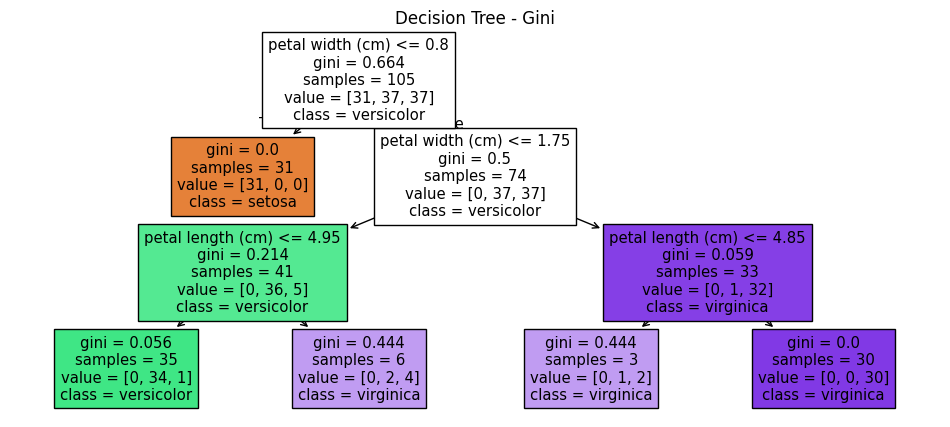

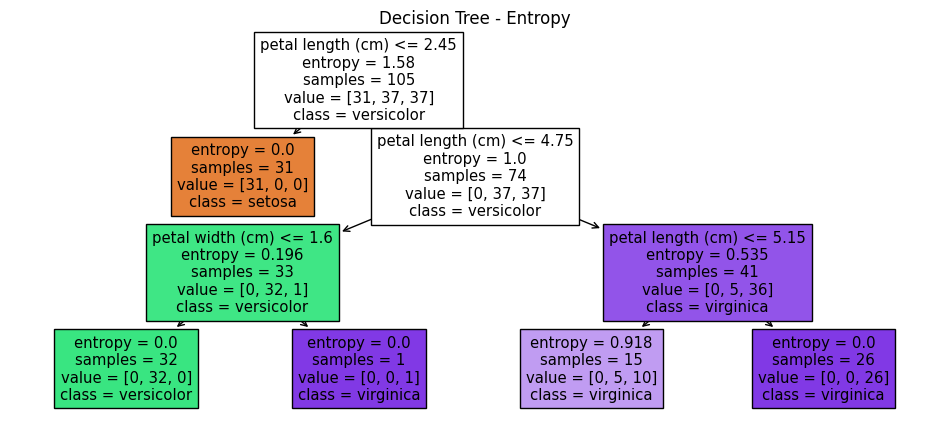

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from math import log2

# -----------------------------
# Part A : Manual Calculations
# -----------------------------

# Sample dataset
data = pd.DataFrame({
    'Feature':[1,2,3,4,5,6],
    'Class':[0,0,0,1,1,1]
})

# Function to calculate Gini
def gini_impurity(labels):
    classes = np.unique(labels)
    gini = 1
    for c in classes:
        p = np.sum(labels == c) / len(labels)
        gini -= p**2
    return gini

# Function to calculate Entropy
def entropy(labels):
    classes = np.unique(labels)
    ent = 0
    for c in classes:
        p = np.sum(labels == c) / len(labels)
        ent -= p * log2(p)
    return ent

# Root calculations
root_gini = gini_impurity(data['Class'])
root_entropy = entropy(data['Class'])

print("Root Gini:",root_gini)
print("Root Entropy:",root_entropy)

# Split example
left = data[data['Feature']<=3]['Class']
right = data[data['Feature']>3]['Class']

gini_left = gini_impurity(left)
gini_right = gini_impurity(right)

weighted_gini = (len(left)/len(data))*gini_left + (len(right)/len(data))*gini_right

print("Weighted Gini after split:",weighted_gini)

# Information Gain
IG = root_entropy - ((len(left)/len(data))*entropy(left) + (len(right)/len(data))*entropy(right))
print("Information Gain:",IG)


# -----------------------------
# Part B : Implementation
# -----------------------------

iris = load_iris()

X = iris.data
y = iris.target

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

# Decision Tree using Gini
gini_tree = DecisionTreeClassifier(criterion='gini',max_depth=3)
gini_tree.fit(X_train,y_train)

# Decision Tree using Entropy
entropy_tree = DecisionTreeClassifier(criterion='entropy',max_depth=3)
entropy_tree.fit(X_train,y_train)

# Predictions
gini_pred = gini_tree.predict(X_test)
entropy_pred = entropy_tree.predict(X_test)

print("Gini Accuracy:",accuracy_score(y_test,gini_pred))
print("Entropy Accuracy:",accuracy_score(y_test,entropy_pred))

# Feature Importance
print("Feature Importance (Gini):",gini_tree.feature_importances_)
print("Feature Importance (Entropy):",entropy_tree.feature_importances_)

# Visualization
plt.figure(figsize=(12,5))
plot_tree(gini_tree,feature_names=iris.feature_names,class_names=iris.target_names,filled=True)
plt.title("Decision Tree - Gini")
plt.show()

plt.figure(figsize=(12,5))
plot_tree(entropy_tree,feature_names=iris.feature_names,class_names=iris.target_names,filled=True)
plt.title("Decision Tree - Entropy")
plt.show()